# Input Testing

  Rasterizing 1011 barangays within DEM extent ...
[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4610)
[InferenceEngine] Model loaded  ← fold_1_best.pth

  Predicting: Triangular, 50.0 mm, tpeak=0.5
  Conditioning: pattern_type=3  depth_norm=0.616  tpeak=0.50  has_tpeak=1

  Flooded area : 33.2%  (2,018 / 6,075 patches)
  Mean confidence : 0.736

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        4,057   66.8%      0.646
  Light               1    0.0%      0.610
  Moderate           63    1.0%      0.387
  Heavy              37    0.6%      0.456
  Extreme         1,917   31.6%      0.944
✓ Saved → outputs\triangular_50mm_tp05.tif


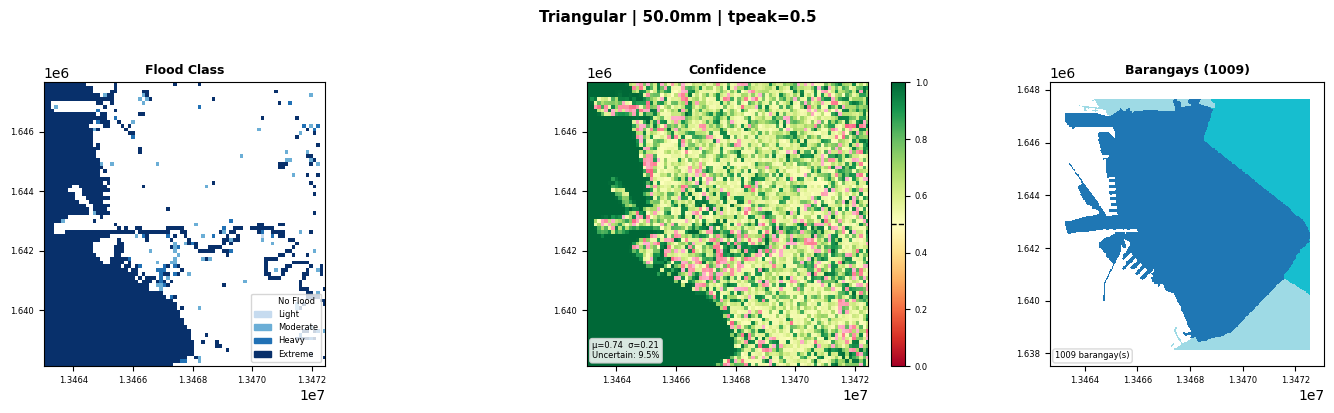

File saved at: outputs\triangular_50mm_tp05.tif


In [1]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine

from config import TrainConfig 
from inference import ( InferenceEngine, _load_barangay_band_from_geojson, run_inference )

cfg = TrainConfig()

# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#C6DBEF', 2: '#6BAED6', 3: '#2171B5', 4: '#08306B'}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_cmap.set_bad(alpha=0)                        
legend_patches = [mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)]
flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

# ── GeoTIFF save helper ───────────────────────────────────────────────────────
src_left, src_top   = 13457490.0, 1664610.0
src_W,    src_H     = 1125,       1224          
dst_W,    dst_H     = 1152,       1152          
src_right           = 13491240.0
src_bottom          = 1627890.0
new_pixel_x = (src_right  - src_left) / dst_W  
new_pixel_y = (src_bottom - src_top)  / dst_H   
dem_transform = Affine(new_pixel_x, 0.0, src_left, 0.0, new_pixel_y, src_top)
dem_crs       = rasterio.crs.CRS.from_epsg(3857)

_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_barangay_band = _load_barangay_band_from_geojson(_GEOJSON_PATH, dem_transform, dem_crs, dst_H, dst_W)
engine = InferenceEngine(patch_data_path = 'outputs/spatial_data.npz')

# Single call for a Triangular storm
res = run_inference(
    engine          = engine,
    storm_type      = 'triangular',
    depth_mm        = 50.0,
    tpeak           = 0.5,
    output_dir      = cfg.output_dir,
    dem_transform   = dem_transform,
    dem_crs         = dem_crs,
    barangay_band   = _barangay_band,
    visualize       = True
)
print(f"File saved at: {res['tif_path']}")


In [2]:
import geopandas as gpd
import pandas as pd

_GEOJSON_PATH = 'manila_barangay_geojson.geojson'
_CITY_LABEL = {'PH1303901': 'Manila City', 'PH1307401': 'Mandaluyong', 'PH1307404': 'Marikina', 'PH1307405': 'Pasig',
    'PH1307501': 'Las Piñas', 'PH1307503': 'Parañaque', 'PH1307602': 'San Juan', 'PH1307605': 'Taguig'}

def _build_barangay_lookup(geojson_path: str) -> dict:
    gdf = gpd.read_file(geojson_path)
    gdf['adm3_pcode'] = gdf['adm3_pcode'].astype(str)

    gdf_all = gdf.dropna(subset=['psgc_code']).copy()
    gdf_all['psgc_int'] = gdf_all['psgc_code'].astype(float).astype(int)

    lookup = {}
    for _, row in gdf_all.iterrows():
        psgc = int(row['psgc_int'])
        city = _CITY_LABEL.get(str(row['adm3_pcode']), str(row['adm3_pcode']))
        
        name = row['adm4_en'] if pd.notna(row['adm4_en']) else f'Barangay (PSGC {psgc})'

        lookup[psgc] = {
            'name'      : name,
            'city'      : city,
            'adm4_pcode': row['adm4_pcode'] if pd.notna(row.get('adm4_pcode')) else '',
            'adm3_pcode': row['adm3_pcode'],
            'area_sqkm' : float(row['shape_sqkm']) if pd.notna(row.get('shape_sqkm')) else 0.0,
        }
    return lookup

BARANGAY_LOOKUP = _build_barangay_lookup(_GEOJSON_PATH)

print(f'BARANGAY_LOOKUP ready  : {len(BARANGAY_LOOKUP):,} entries')
print(f'PSGC range             : {min(BARANGAY_LOOKUP):,} – {max(BARANGAY_LOOKUP):,}')
print(f'Cities                 : {sorted(set(v["city"] for v in BARANGAY_LOOKUP.values()))}')


BARANGAY_LOOKUP ready  : 4,560 entries
PSGC range             : 330,100,001 – 1,999,908,008
Cities                 : ['Las Piñas', 'Mandaluyong', 'Manila City', 'Marikina', 'None', 'Parañaque', 'Pasig', 'San Juan', 'Taguig']
